In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
df = pd.read_csv("heart_disease.csv")

print("First 5 rows:")
df.head()

First 5 rows:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [3]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

print("Columns:")
df.columns

Columns:


Index(['Age', 'Gender', 'Blood_Pressure', 'Cholesterol_Level',
       'Exercise_Habits', 'Smoking', 'Family_Heart_Disease', 'Diabetes', 'BMI',
       'High_Blood_Pressure', 'Low_HDL_Cholesterol', 'High_LDL_Cholesterol',
       'Alcohol_Consumption', 'Stress_Level', 'Sleep_Hours',
       'Sugar_Consumption', 'Triglyceride_Level', 'Fasting_Blood_Sugar',
       'CRP_Level', 'Homocysteine_Level', 'Heart_Disease_Status'],
      dtype='object')

In [4]:
print("Missing Values:")
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)

Missing Values:
Age                       29
Gender                    19
Blood_Pressure            19
Cholesterol_Level         30
Exercise_Habits           25
Smoking                   25
Family_Heart_Disease      21
Diabetes                  30
BMI                       22
High_Blood_Pressure       26
Low_HDL_Cholesterol       25
High_LDL_Cholesterol      26
Alcohol_Consumption     2586
Stress_Level              22
Sleep_Hours               25
Sugar_Consumption         30
Triglyceride_Level        26
Fasting_Blood_Sugar       22
CRP_Level                 26
Homocysteine_Level        20
Heart_Disease_Status       0
dtype: int64
Shape after cleaning: (10000, 21)


In [5]:
target = 'Heart_Disease_Status'

df[target] = df[target].map({'No': 0, 'Yes': 1})

print("Target values:")
df[target].unique()

Target values:


array([0, 1])

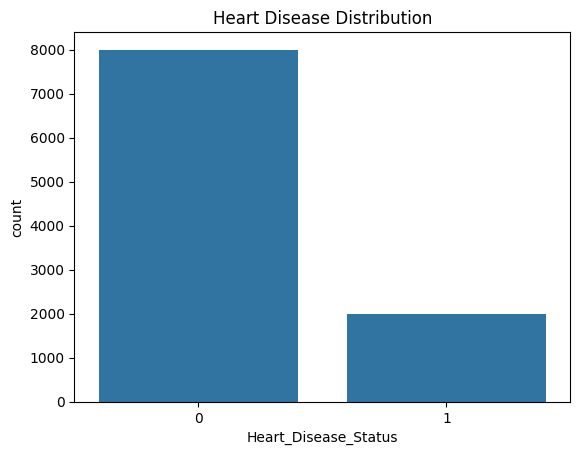

In [6]:
plt.figure()
sns.countplot(x=target, data=df)
plt.title("Heart Disease Distribution")
plt.show()

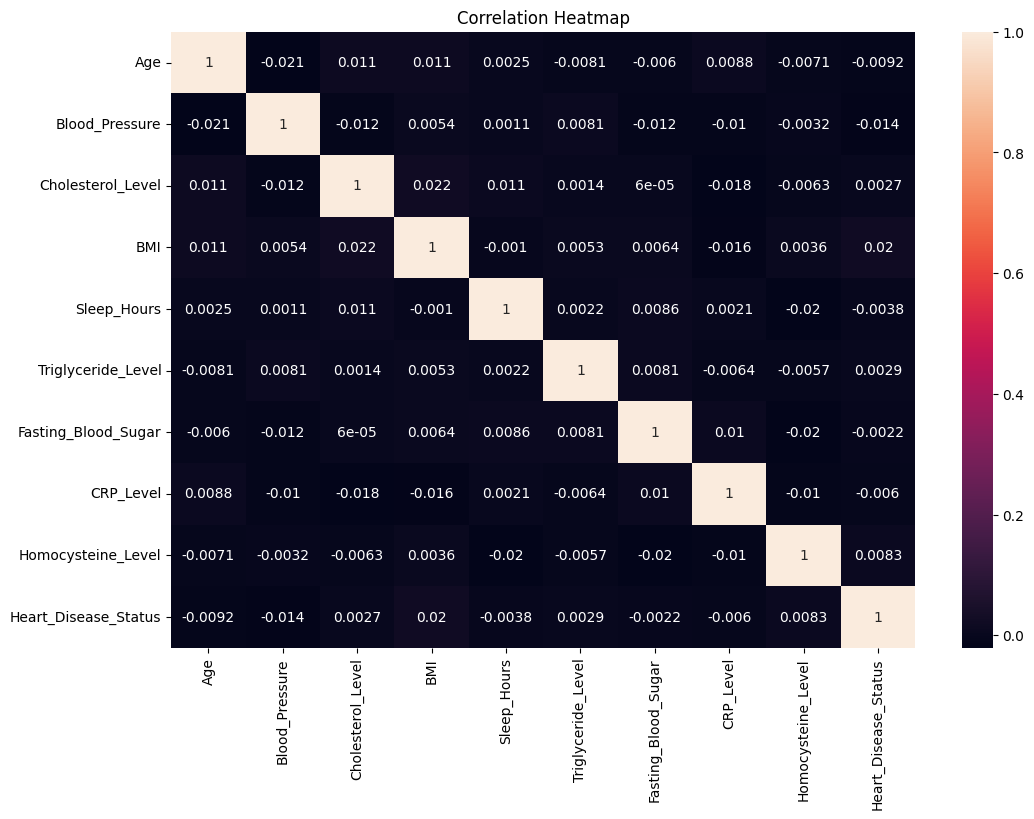

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

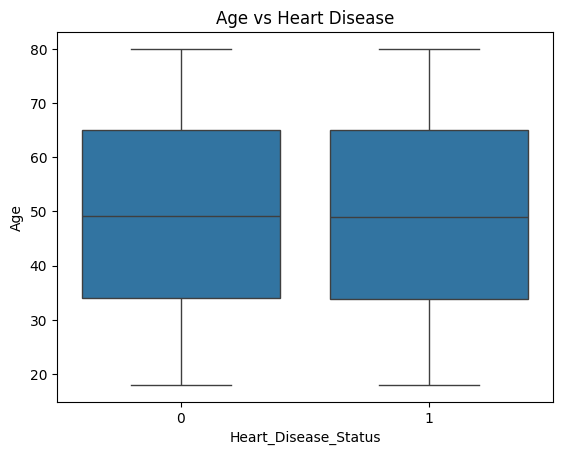

In [8]:
plt.figure()
sns.boxplot(x=target, y='Age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

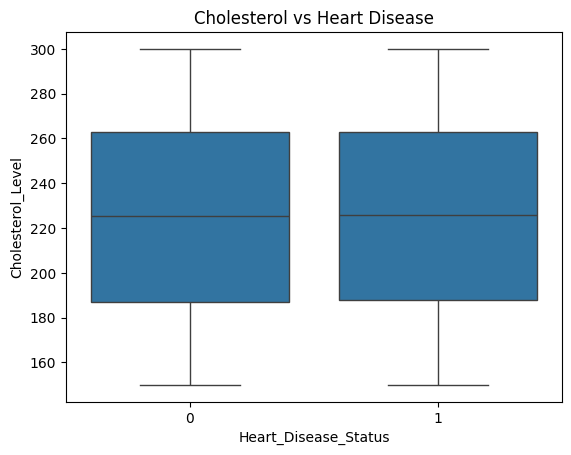

In [9]:
plt.figure()
sns.boxplot(x=target, y='Cholesterol_Level', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

In [10]:
X = df.drop(target, axis=1)
y = df[target]

X = pd.get_dummies(X, drop_first=True)

print("Encoded shape:", X.shape)

Encoded shape: (10000, 24)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [13]:
print("Accuracy:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Accuracy:
Logistic Regression: 0.8065
Decision Tree: 0.6695


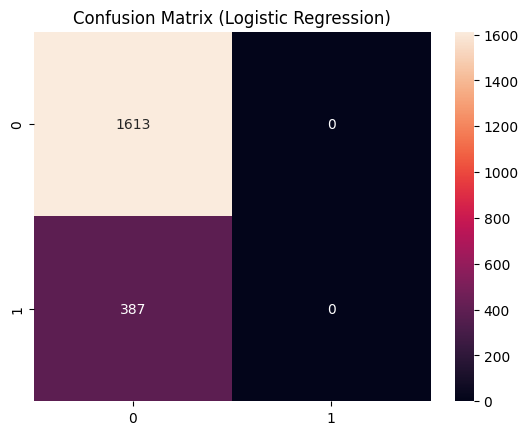

In [14]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

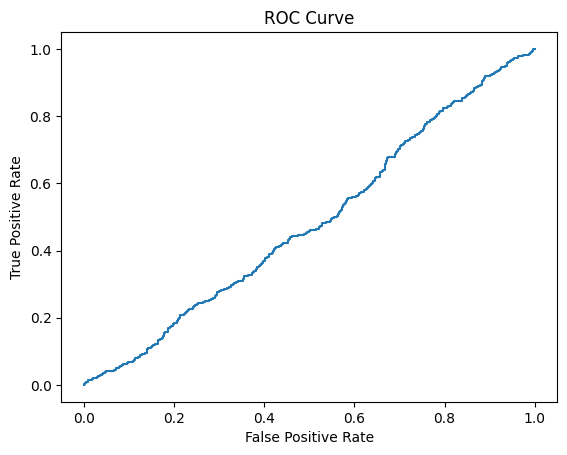

ROC-AUC Score: 0.48392181740413404


In [15]:
y_prob = lr.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

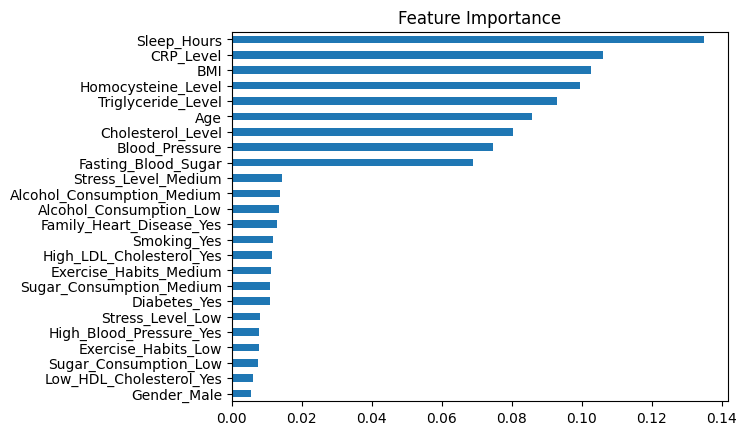

In [16]:
importance = dt.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)

plt.figure()
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [17]:
print("Project Completed Successfully!")

Project Completed Successfully!
